In [1]:
import geopandas as gpd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pandas as pd

import time

In [2]:
indig = gpd.read_file("data/IPL_IndigenousPeoplesLands_2017/01_Data/IPL_IndigenousPeoplesLands_2017/IPL_2017.shp")


In [3]:
indig.shape

(88, 2)

In [4]:
indig_pro = indig.to_crs(epsg=4326)

In [5]:
indig_pro.columns

Index(['Name_', 'geometry'], dtype='object')

In [6]:
indig_in = indig_pro.set_index('Name_')

In [7]:
indig_in = indig_pro.explode()

C:\Users\admin\AppData\Local\Temp\ipykernel_27804\1514193147.py:1: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  indig_in = indig_pro.explode()


In [8]:
indig_in.shape

(78504, 2)

In [9]:
def geo_plot(gdf, name, projection= ccrs.PlateCarree()):

    
        # Create a figure and axis with a specified projection
    fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})

    gdf.plot(ax=ax, transform = projection)

    # Add coastlines and land features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Customize gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    ax.set_axis_off()

    # Show the plot
    plt.tight_layout()  # Adjust layout to prevent overlap

    plt.savefig(f'fig/{name}'+'.png', dpi=300)
    plt.show()

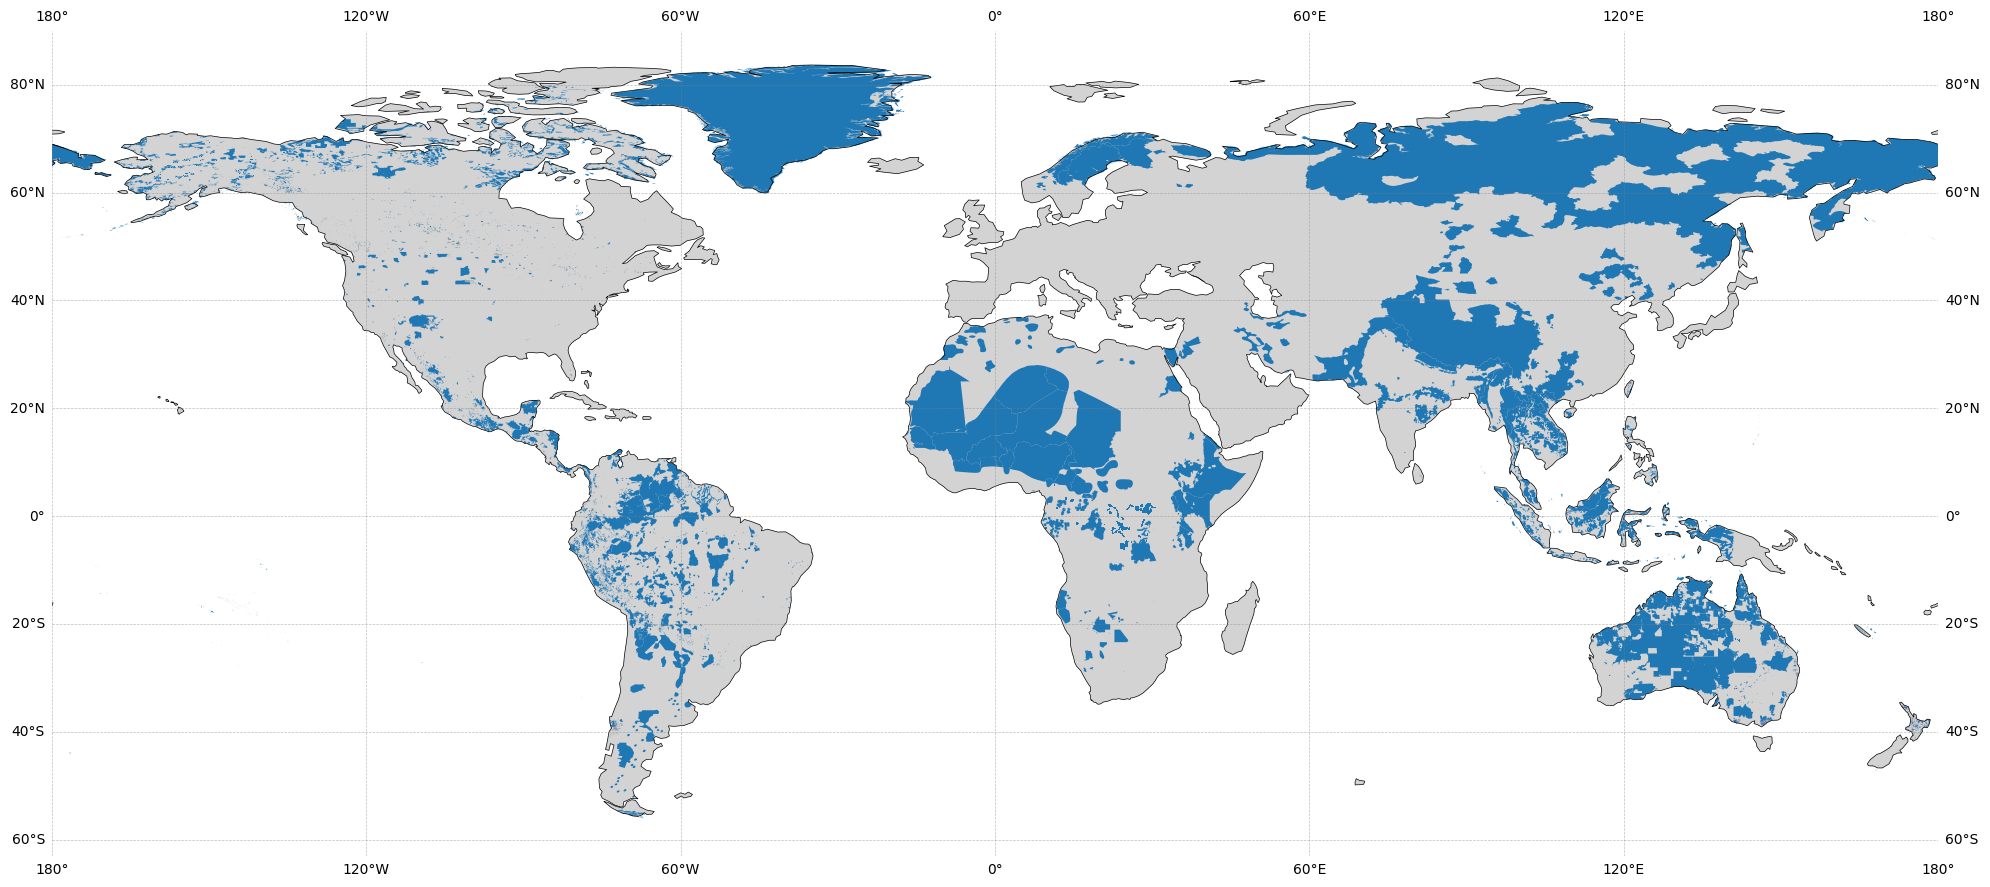

In [10]:

geo_plot(indig_pro, 'indigenous_land_areas')


In [11]:
indig_raster = gpd.read_file("data/IPL_IndigenousPeoplesLands_2017/01_Data/IPL_IndigenousPeoplesLands_100kmGrid_2017/IPL_2017_100kmGrid.shp")

In [12]:
indig_raster_pro = indig_raster.to_crs(epsg=4326)

In [13]:
indig_raster_pro.shape

(18440, 6)

In [14]:
indig_raster_pro.head(20)

,GRID_SQKM,IPL_SQKM,IPL_PC,gadm_SQKM,IPL_PCgadm,geometry
0,10000.0,0.0,0.0,210.720104,0,"POLYGON ((inf inf, inf inf, -174.74607 -86.968..."
1,10000.0,0.0,0.0,928.464945,0,"POLYGON ((inf inf, -174.74607 -86.96899, -168...."
2,10000.0,0.0,0.0,1610.343427,0,"POLYGON ((inf inf, -168.02667 -86.96899, -161...."
3,10000.0,0.0,0.0,2285.417163,0,"POLYGON ((inf inf, -161.30728 -86.96899, -154...."
4,10000.0,0.0,0.0,2941.165628,0,"POLYGON ((inf inf, -154.58789 -86.96899, -147...."
5,10000.0,0.0,0.0,3535.080573,0,"POLYGON ((inf inf, -147.86849 -86.96899, -141...."
6,10000.0,0.0,0.0,4124.357343,0,"POLYGON ((inf inf, -141.14910 -86.96899, -134...."
7,10000.0,0.0,0.0,4699.955429,0,"POLYGON ((inf inf, -134.42970 -86.96899, -127...."
8,10000.0,0.0,0.0,5206.640662,0,"POLYGON ((inf inf, -127.71031 -86.96899, -120...."
9,10000.0,0.0,0.0,5703.785754,0,"POLYGON ((inf inf, -120.99091 -86.96899, -114...."


In [15]:
mines = gpd.read_file("data\mine-comm\global_mining_land_use_comm.gpkg")

In [16]:
mines.columns

Index(['area', 'admin', 'adm0_a3', 'row.id', 'list_of_commodities',
       'geometry'],
      dtype='object')

In [17]:
minesid = mines.set_index('row.id')

In [18]:
minesid

,area,admin,adm0_a3,list_of_commodities,geometry
row.id,,,,,
1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."
...,...,...,...,...,...
81558,0.055417,China,CHN,None,"MULTIPOLYGON (((110.92507 41.11132, 110.92504 ..."
81559,0.034229,China,CHN,None,"MULTIPOLYGON (((110.91125 41.10848, 110.91125 ..."
81560,0.031565,China,CHN,None,"MULTIPOLYGON (((110.91224 41.10593, 110.91222 ..."


In [19]:
minesid.head()

,area,admin,adm0_a3,list_of_commodities,geometry
row.id,,,,,
1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."


In [20]:
indig_pro.head()

,Name_,geometry
0,ARG,"MULTIPOLYGON Z (((-68.90305 -51.71368 0.00000,..."
1,ASM,MULTIPOLYGON Z (((-168.14500 -14.54528 0.00000...
2,AUS,"MULTIPOLYGON Z (((147.36668 -43.17054 0.00000,..."
3,BDI,"MULTIPOLYGON Z (((29.33815 -3.65799 0.00000, 2..."
4,BEN,"POLYGON Z ((2.89049 12.36722 0.00000, 2.90662 ..."


In [21]:
indig_ex = indig_pro.explode()

C:\Users\admin\AppData\Local\Temp\ipykernel_27804\3838390920.py:1: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  indig_ex = indig_pro.explode()


In [22]:
indig_ex.shape

(78504, 2)

In [23]:
indig_ex.reset_index(inplace=True)

In [24]:
indig_ex.head()

,level_0,level_1,Name_,geometry
0,0,0,ARG,"POLYGON Z ((-68.90305 -51.71368 0.00000, -68.9..."
1,0,1,ARG,"POLYGON Z ((-71.93108 -51.17015 0.00000, -72.0..."
2,0,2,ARG,"POLYGON Z ((-70.61048 -50.96789 0.00000, -70.7..."
3,0,3,ARG,"POLYGON Z ((-73.12081 -50.32544 0.00000, -73.2..."
4,0,4,ARG,"POLYGON Z ((-72.24041 -49.82575 0.00000, -72.4..."


In [25]:
indig_ex.drop(columns=['level_0', 'level_1'], inplace=True)

In [26]:
indig_ex.set_index('Name_', inplace=True)

# Footprinting

In [27]:
minesid.head()

,area,admin,adm0_a3,list_of_commodities,geometry
row.id,,,,,
1,0.038096,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
2,0.114247,New Zealand,NZL,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
3,0.125528,New Zealand,NZL,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
4,0.288590,New Zealand,NZL,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
5,0.349819,New Zealand,NZL,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."


In [28]:

def calc_inter(mland, iland, buffer_list=[0, 10, 30, 50], crs_epsg=6933):
    # Convert both GeoDataFrames to an equal-area CRS
    mland_pro = mland.to_crs(epsg=crs_epsg) 
    mland_pro['ID'] = mland_pro.index

    iland_pro = iland.to_crs(epsg=crs_epsg)

    over_dis_collect = []

    for i, buffer in enumerate(buffer_list):
        start_time = time.time()  # Start the timer
        
        mland_buffered = mland_pro.copy()
        mland_buffered['geometry'] = mland_pro.buffer(buffer*10**3)
        over = gpd.overlay(mland_buffered, iland_pro, how='intersection') 
        
        over_dis = over.dissolve(by='ID')

        over_dis['area_km2'] = over_dis.area * 10**(-6) ## error must be -9 fixed

        over_dis['buffer'] = buffer

        over_dis_collect.append(over_dis)

        elapsed_time = time.time() - start_time  # Calculate elapsed time
        print(f'Buffer: {buffer}km, Number of mines: {over_dis.shape}, Elapsed Time: {elapsed_time/60:.2f} min, Buffers left: {len(buffer_list)-i-1}'
        )

    over_df = pd.concat(over_dis_collect, axis=0)

    return over_df


join_direct = calc_inter(mland=minesid, iland = indig_ex, buffer_list=[0, 10, 30, 50])

Buffer: 0km, Number of mines: (10908, 7), Elapsed Time: 8.19 min, Buffers left: 3
Buffer: 10km, Number of mines: (17134, 7), Elapsed Time: 10.35 min, Buffers left: 2
Buffer: 30km, Number of mines: (24948, 7), Elapsed Time: 16.10 min, Buffers left: 1
Buffer: 50km, Number of mines: (30378, 7), Elapsed Time: 32.07 min, Buffers left: 0


In [29]:
join_direct.shape

(83368, 7)

In [30]:
join_direct.to_file('data/interm/mine_indig_footprint.gpkg', driver='GPKG')

In [31]:
join_direct.index

Index([   23,    30,    36,    37,    38,    39,    40,    42,    44,    45,
       ...
       81410, 81411, 81412, 81417, 81418, 81419, 81424, 81426, 81427, 81428],
      dtype='int64', name='ID', length=83368)

In [32]:
join_meter = join_direct.to_crs('3857')

In [33]:
join_direct['direct_fp'] = join_meter.area

In [34]:
join_direct.head(20)

,geometry,area,admin,adm0_a3,list_of_commodities,area_km2,buffer,direct_fp
ID,,,,,,,,
23,"POLYGON Z ((14729392.922 -3395167.129 0.000, 1...",0.040195,Australia,AUS,Coal,0.040131,0,5.134195e+04
30,MULTIPOLYGON Z (((13644203.534 -3875200.456 0....,0.372366,Australia,AUS,"Copper,U3O8,Gold,Zinc,Lead,Silver,Platinum,Nic...",0.065049,0,9.065321e+04
36,"POLYGON Z ((13467053.269 -3679156.546 0.000, 1...",0.048309,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.048257,0,6.479757e+04
37,"POLYGON Z ((13465345.462 -3679101.220 0.000, 1...",0.242487,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.242234,0,3.252915e+05
38,"POLYGON Z ((13465248.975 -3671541.182 0.000, 1...",0.172674,Australia,AUS,"U3O8,Copper,Molybdenum,Lithium,Tungsten,Niobiu...",0.172483,0,2.312925e+05
39,"POLYGON Z ((13057565.495 -3622771.392 0.000, 1...",0.058386,Australia,AUS,None,0.058316,0,7.751827e+04
40,"POLYGON Z ((12747892.779 -3759855.667 0.000, 1...",0.088466,Australia,AUS,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands",0.088383,0,1.204671e+05
42,"POLYGON Z ((11882922.222 -3858019.570 0.000, 1...",18.898402,Australia,AUS,"Gold,Nickel,Copper,Cobalt,Platinum,Chromite,Pa...",18.884053,0,2.623262e+07
44,"POLYGON Z ((11750649.181 -3920264.596 0.000, 1...",0.461226,Australia,AUS,"Gold,Nickel,Copper,Silver,Lithium,Cobalt,Zinc,...",0.460942,0,6.484015e+05


In [35]:
geo_plot(join_direct, 'Direct land use footprint')

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x00000247AC9727A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 